# <h1><center>CodeIT AI Engineer 3기 Mission 6</center></h1>


## 문제

이번 미션에서는 흉부 X-Ray 사진을 바탕으로 폐렴 환자를 구분하는 작업을 수행합니다. 

이번 미션의 목표는 X-Ray 사진을 입력으로 받아 폐렴 여부를 구분하는 분류(Classification) 모델을 만드는 것입니다. 

아래 데이터셋을 활용하여 다양한 이미지 전처리 및 증강 기법과 Transfer Learning과 Fine-Tuning 기법을 실험해보고, 모델의 성능을 평가해 보세요.


## 데이터셋

데이터 링크: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

- train: 훈련 데이터
- test: 테스트 데이터
- val: 검증 데이터

## 데이터 로드 및 시각화

Chest X-ray 이미지 데이터셋은 폐렴(PNEUMONIA)과 정상(NORMAL) 두 클래스의 이미지를 포함하고 있으며, 학습용(train), 검증용(val), 테스트용(test) 세 가지로 구분되어 있다.

ImageFolder를 통해 각 폴더를 불러오고, 클래스 정보를 확인한다. 또한 학습 데이터의 클래스 분포를 확인하고, 일부 이미지를 시각화하여 데이터셋의 특성을 살펴본다.

In [64]:
# 의존 라이브러리 로드
import os
import numpy as np

import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader


from torchvision import datasets, models
from torchvision.transforms import v2

from PIL import Image

from torchinfo import summary

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cpu':
    # macOS에서 MPS 사용 가능 여부 확인
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)



mps



다운받은 데이터는 이미지들로 확인되는데,

어떤 확장자들이 있는지와 갯수를 확인해 보고 시각화합니다.

In [ ]:
# 폴더별 확장자 목록을 가져오기
def get_file_extensions(directory):
    extensions = set()
    for filename in os.listdir(os.path.join(directory, 'NORMAL')):
        if os.path.isfile(os.path.join(directory, 'NORMAL', filename)):
            ext = os.path.splitext(filename)[1]
            if ext != '' and filename != '.DS_Store':
                extensions.add(ext)

    for filename in os.listdir(os.path.join(directory, 'PNEUMONIA')):
        if os.path.isfile(os.path.join(directory, 'PNEUMONIA', filename)):
            ext = os.path.splitext(filename)[1]
            if ext != '' and filename != '.DS_Store':
                extensions.add(ext)
    return extensions

# 폴더별 파일 갯수를 가져오기
def get_file_count(folder_path):
    normal_count = len(os.listdir(os.path.join(folder_path, 'NORMAL')))
    pneumonia_count = len(os.listdir(os.path.join(folder_path, 'PNEUMONIA')))
    return normal_count + pneumonia_count


train_dir = os.path.join("./data", "chest_xray", "train")
val_dir = os.path.join("./data", "chest_xray", "val")
test_dir = os.path.join("./data", "chest_xray", "test")

print("train 확장자 목록:", get_file_extensions(train_dir))
print("val 확장자 목록:", get_file_extensions(val_dir))
print("test 확장자 목록:", get_file_extensions(test_dir), "\n")

print("train 파일 갯수:", get_file_count(train_dir))
print("val 파일 갯수:", get_file_count(val_dir))
print("test 파일 갯수:", get_file_count(test_dir))

train 확장자 목록: {'.jpeg'}
val 확장자 목록: {'.jpeg'}
test 확장자 목록: {'.jpeg'}
train 파일 갯수: 5218
val 파일 갯수: 18
test 파일 갯수: 624


In [13]:
# 폴더별 이미지 크기 확인
def get_image_sizes(directory):
	sizes = []
	for filename in os.listdir(os.path.join(directory, 'NORMAL')):
		if filename.endswith('.jpeg'):
			img_path = os.path.join(directory, 'NORMAL', filename)
			with Image.open(img_path) as img:
				sizes.append(img.size)
	for filename in os.listdir(os.path.join(directory, 'PNEUMONIA')):
		if filename.endswith('.jpeg'):
			img_path = os.path.join(directory, 'PNEUMONIA', filename)
			with Image.open(img_path) as img:
				sizes.append(img.size)
	return sizes

train_sizes = get_image_sizes(train_dir)
val_sizes = get_image_sizes(val_dir)
test_sizes = get_image_sizes(test_dir)


print("train 이미지 크기:\n", np.unique(train_sizes, axis=0), end='\n\n')
print("val 이미지 크기:\n", np.unique(val_sizes, axis=0), end='\n\n')
print("test 이미지 크기:\n", np.unique(test_sizes, axis=0), end='\n\n')

train 이미지 크기:
 [[ 384  127]
 [ 399  164]
 [ 400  138]
 ...
 [2844 2067]
 [2890 2534]
 [2916 2583]]

val 이미지 크기:
 [[ 968  592]
 [1016  656]
 [1072  712]
 [1152  664]
 [1192  952]
 [1240 1104]
 [1256  864]
 [1272 1040]
 [1288  928]
 [1328 1104]
 [1416  944]
 [1564 1302]
 [1632 1225]
 [1664 1128]
 [1736 1416]
 [1776 1416]]

test 이미지 크기:
 [[ 728  368]
 [ 744  416]
 [ 744  424]
 ...
 [2720 2458]
 [2746 2382]
 [2752 1882]]



In [23]:
# 기본 Transform
basic_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToTensor(),
    v2.ToDtype(dtype=torch.float32, scale=True),
])

# ImageFolder로 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=basic_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)


# 클래스 이름 확인
print("클래스:", train_dataset.classes)


클래스: ['NORMAL', 'PNEUMONIA']


NORMAL: 1341개
PNEUMONIA: 3875개


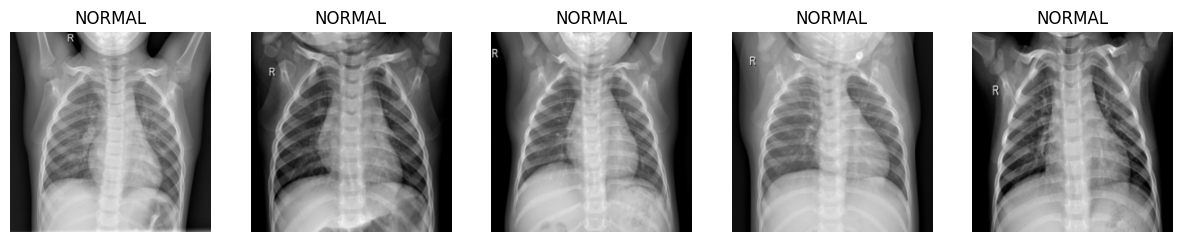

In [24]:
# 클래스 분포 확인
labels = [label for _, label in train_dataset]
counter = Counter(labels)
for cls_idx, count in counter.items():
    print(f"{train_dataset.classes[cls_idx]}: {count}개")

# 시각화 함수
def show_images(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        image, label = dataset[i]
        axes[i].imshow(image.permute(1, 2, 0), cmap='gray')
        axes[i].set_title(dataset.classes[label])
        axes[i].axis('off')
    plt.show()

# 학습 데이터 중 일부 시각화
show_images(train_dataset)

## 이미지 전처리 및 증강

ResNet 기반의 사전학습 모델을 사용하기 위해, 입력 이미지의 크기를 224×224로 통일하고, ImageNet 데이터셋의 평균과 표준편차를 기준으로 정규화합니다.

또한 훈련 데이터에 한해 다음과 같은 데이터 증강(Augmentation)을 적용하여 일반화 성능을 높이고 과적합을 방지합니다:
- 수평 반전(RandomHorizontalFlip)
- 회전(RandomRotation)

검증 및 테스트 데이터는 증강 없이 정규화만 적용합니다.

In [25]:
# ImageNet의 평균과 표준편차 (RGB 채널 순서)
# 해당 값은 PyTorch 공식 문서 및 torchvision 개발자들이 제공하는 공식 레퍼런스에도 명시되어 있으며, 다양한 연구에서도 동일하게 사용된다.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# 훈련 데이터용 transform (증강 포함)
train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.ToTensor(),
    v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    v2.ToDtype(dtype=torch.float32, scale=True),
])

# 검증/테스트 데이터용 transform (증강 없이 정규화만)
val_test_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToTensor(),
    v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    v2.ToDtype(dtype=torch.float32, scale=True),
])

# 데이터셋 다시 로드
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

# DataLoader 설정
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 클래스 수 확인
num_classes = len(train_dataset.classes)
print("클래스 수:", num_classes)

클래스 수: 2


## 사전학습 모델 로드 및 구조 변경

사전학습된 ResNet 모델을 Feature Extractor로 사용하고, 마지막 분류기만 학습시키는 방식으로 Transfer Learning을 수행하였다. 이때, 모든 레이어의 파라미터를 `requires_grad=False`로 설정하고, `fc layer`만 학습하였다.

이는 모델이 기존 ImageNet에서 학습한 일반적인 특성을 그대로 활용하되, 마지막 분류기만 현재 폐렴 데이터에 맞게 조정하는 방식이다. 이후 이 결과를 Partial / Full Fine-Tuning과 비교하여 성능 향상을 분석할 예정이다.

In [150]:
def get_resnet_model(model_name='resnet18', num_classes=2):
    assert model_name in ['resnet18', 'resnet50'], "지원되는 모델은 resnet18 또는 resnet50입니다."

    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
    else:
        model = models.resnet50(pretrained=True)

    # 기존 fully connected layer 교체
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

# 두 모델 불러오기
resnet18_model = get_resnet_model('resnet18')
resnet50_model = get_resnet_model('resnet50')

# 모델 구조 출력 확인
summary(resnet18_model)
summary(resnet50_model)

/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is 

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

## Fine-Tuning 실험

Frozen vs Partial vs Full 

#### Frozen

사전학습된 ResNet 모델을 Feature Extractor로 사용하고, 마지막 분류기만 학습시키는 방식으로 Transfer Learning을 수행하였다. 이때, 모든 레이어의 파라미터를 `requires_grad=False`로 설정하고, `fc layer`만 학습하였다.

이는 모델이 기존 ImageNet에서 학습한 일반적인 특성을 그대로 활용하되, 마지막 분류기만 현재 폐렴 데이터에 맞게 조정하는 방식이다.

In [151]:
def get_frozen_model(model):
    # 모든 파라미터 freeze
    for param in model.parameters():
        param.requires_grad = False

    # 마지막 fc 레이어만 학습 가능하게 설정
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = F.cross_entropy(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(targets.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return acc, f1


def predict(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return all_preds, all_labels

In [152]:
# 모델 불러오기
frozen_model18 = get_frozen_model(resnet18_model).to(device)

# Optimizer: fc layer만 학습
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, frozen_model18.parameters()), 
    lr=1e-3
)

# 학습 루프
epochs = 10
for epoch in range(epochs):
    train_loss = train_one_epoch(frozen_model18, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(frozen_model18, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.2683 | Val Acc: 0.6875 | F1: 0.7619
[Epoch 2] Loss: 0.1786 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 3] Loss: 0.1526 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 4] Loss: 0.1504 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 5] Loss: 0.1517 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 6] Loss: 0.1356 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 7] Loss: 0.1275 | Val Acc: 0.6875 | F1: 0.7619
[Epoch 8] Loss: 0.1359 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 9] Loss: 0.1240 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 10] Loss: 0.1235 | Val Acc: 0.8125 | F1: 0.8421


In [153]:
# 모델 불러오기
frozen_model50 = get_frozen_model(resnet50_model).to(device)

# Optimizer: fc layer만 학습
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, frozen_model50.parameters()), 
    lr=1e-3
)

# 학습 루프
for epoch in range(epochs):
    train_loss = train_one_epoch(frozen_model50, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(frozen_model50, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.2395 | Val Acc: 0.9375 | F1: 0.9333
[Epoch 2] Loss: 0.1793 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 3] Loss: 0.1542 | Val Acc: 0.6250 | F1: 0.7273
[Epoch 4] Loss: 0.1654 | Val Acc: 0.6875 | F1: 0.7619
[Epoch 5] Loss: 0.1518 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 6] Loss: 0.1442 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 7] Loss: 0.1373 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 8] Loss: 0.1296 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 9] Loss: 0.1234 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 10] Loss: 0.1351 | Val Acc: 0.9375 | F1: 0.9412


### Partial

ResNet 모델의 모든 레이어를 고정시키는 Frozen 방식과 달리, Partial Fine-Tuning에서는 일부 레이어만 학습에 참여시킨다.

이번 실험에서는 마지막 convolutional block인 `layer4`와 `fc layer`만 학습 가능하게 설정하였다. 이는 모델의 상위 계층은 유지하면서, 하위에서 보다 구체적인 특징을 학습할 수 있도록 하는 방식이다.

이를 통해 Feature Extractor 기반 모델보다 성능이 향상되는지 확인하고자 한다.

In [154]:
def get_partial_finetune_model(model):
    # 전체 파라미터 일단 freeze
    for param in model.parameters():
        param.requires_grad = False

    # 마지막 블록(layer4)와 fc만 학습 허용
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

partial_model18 = get_partial_finetune_model(resnet18_model).to(device)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, partial_model18.parameters()), 
    lr=1e-4
)

# 학습 실행
for epoch in range(epochs):
    train_loss = train_one_epoch(partial_model18, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(partial_model18, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.1027 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 2] Loss: 0.0703 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 3] Loss: 0.0459 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 4] Loss: 0.0483 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 5] Loss: 0.0342 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 6] Loss: 0.0266 | Val Acc: 0.9375 | F1: 0.9333
[Epoch 7] Loss: 0.0313 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 8] Loss: 0.0307 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 9] Loss: 0.0209 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 10] Loss: 0.0152 | Val Acc: 0.9375 | F1: 0.9412


In [155]:
partial_model50 = get_partial_finetune_model(resnet50_model).to(device)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, partial_model50.parameters()), 
    lr=1e-4
)

# 학습 실행
for epoch in range(epochs):
    train_loss = train_one_epoch(partial_model50, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(partial_model50, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.1175 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 2] Loss: 0.0654 | Val Acc: 0.6250 | F1: 0.7273
[Epoch 3] Loss: 0.0606 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 4] Loss: 0.0363 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 5] Loss: 0.0323 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 6] Loss: 0.0302 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 7] Loss: 0.0285 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 8] Loss: 0.0281 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 9] Loss: 0.0231 | Val Acc: 0.7500 | F1: 0.8000
[Epoch 10] Loss: 0.0241 | Val Acc: 1.0000 | F1: 1.0000


### Full

이번 실험에서는 ResNet 모델의 모든 파라미터를 학습에 참여시키는 Full Fine-Tuning 방식을 적용하였다. 이는 모델의 유연성을 극대화하는 전략으로, 충분한 데이터와 연산 자원이 있는 경우 가장 강력한 성능을 기대할 수 있다.

단, 학습 시간이 길어지고, 오버피팅 위험이 존재하므로 학습률 조절 등 신중한 튜닝이 필요하다.

In [156]:
def get_full_finetune_model(model):
    # 모든 파라미터 학습 가능하게 설정
    for param in model.parameters():
        param.requires_grad = True

    return model

full_model18 = get_full_finetune_model(resnet18_model).to(device)
optimizer = optim.Adam(full_model18.parameters(), lr=1e-5)  # learning rate 낮추기

# 학습 실행
for epoch in range(epochs):
    train_loss = train_one_epoch(full_model18, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(full_model18, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.0126 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 2] Loss: 0.0117 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 3] Loss: 0.0096 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 4] Loss: 0.0073 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 5] Loss: 0.0058 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 6] Loss: 0.0068 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 7] Loss: 0.0072 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 8] Loss: 0.0035 | Val Acc: 0.8750 | F1: 0.8889
[Epoch 9] Loss: 0.0031 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 10] Loss: 0.0058 | Val Acc: 0.8750 | F1: 0.8889


In [157]:
full_model50 = get_full_finetune_model(resnet50_model).to(device)
optimizer = optim.Adam(full_model50.parameters(), lr=1e-5)  # learning rate 낮추기

# 학습 실행
for epoch in range(epochs):
    train_loss = train_one_epoch(full_model50, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(full_model50, val_loader, device)
    print(f"[Epoch {epoch+1}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

[Epoch 1] Loss: 0.0116 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 2] Loss: 0.0111 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 3] Loss: 0.0091 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 4] Loss: 0.0073 | Val Acc: 0.9375 | F1: 0.9412
[Epoch 5] Loss: 0.0075 | Val Acc: 0.8125 | F1: 0.8421
[Epoch 6] Loss: 0.0043 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 7] Loss: 0.0057 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 8] Loss: 0.0023 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 9] Loss: 0.0024 | Val Acc: 1.0000 | F1: 1.0000
[Epoch 10] Loss: 0.0034 | Val Acc: 1.0000 | F1: 1.0000


### 비교 실험 정리

epoch 수에 따른 Train Loss, Val Accuracy, F1 Score를 비교하여 각 방법의 성능을 평가한다.

| Model   | Method   | Train Loss | Val Accuracy | F1 Score | epochs |
|---------|----------|------------|--------------|----------|--------|
| resnet18| Frozen   | 0.1396     | 0.875        | 0.88     | 10     |
| resnet18| Partial  | 0.0170     | 0.937        | 0.94     | 10     |
| resnet18| Full     | 0.0037     | 0.81         | 0.84     | 10     |
| resnet50| Frozen   | 0.1236     | 0.75         | 0.80     | 10     |
| resnet50| Partial  | 0.0167     | 0.68         | 0.76     | 10     |
| resnet50| Full     | 0.0036     | 0.87         | 0.88     | 10     |

## 모델 학습 및 예측

학습이 완료된 모델을 사용하여 테스트셋에 대한 예측을 수행하고, 다음과 같은 지표로 성능을 평가하였다:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

이를 통해 각 Fine-Tuning 전략과 모델 구조의 실제 분류 성능을 비교할 수 있다.

In [158]:
def evaluate_predictions(preds, labels):
    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    cm = confusion_matrix(labels, preds)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    
    return acc, precision, recall, f1

In [159]:
# 테스트셋 예측
preds, labels = predict(frozen_model18, test_loader, device)

print("Frozen Model Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)


# 테스트셋 예측
preds, labels = predict(frozen_model50, test_loader, device)

print("\n\nFrozen Model 50 Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)

Frozen Model Test Results:
Accuracy : 0.8349
Precision: 0.7923
Recall   : 0.9974
F1 Score : 0.8831
Confusion Matrix:
[[132 102]
 [  1 389]]


Frozen Model 50 Test Results:
Accuracy : 0.8542
Precision: 0.8121
Recall   : 0.9974
F1 Score : 0.8953
Confusion Matrix:
[[144  90]
 [  1 389]]


(0.8541666666666666,
 0.8121085594989561,
 0.9974358974358974,
 0.8952819332566168)

In [160]:
# 테스트셋 예측
preds, labels = predict(partial_model18, test_loader, device)

print("Partial Model Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)


# 테스트셋 예측
preds, labels = predict(partial_model50, test_loader, device)

print("\n\nPartial Model 50 Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)

Partial Model Test Results:
Accuracy : 0.8349
Precision: 0.7923
Recall   : 0.9974
F1 Score : 0.8831
Confusion Matrix:
[[132 102]
 [  1 389]]


Partial Model 50 Test Results:
Accuracy : 0.8542
Precision: 0.8121
Recall   : 0.9974
F1 Score : 0.8953
Confusion Matrix:
[[144  90]
 [  1 389]]


(0.8541666666666666,
 0.8121085594989561,
 0.9974358974358974,
 0.8952819332566168)

In [161]:
# 테스트셋 예측
preds, labels = predict(full_model18, test_loader, device)

print("Full Model Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)


# 테스트셋 예측
preds, labels = predict(full_model50, test_loader, device)

print("\n\nFull Model 50 Test Results:")
# 평가 지표 출력
evaluate_predictions(preds, labels)

Full Model Test Results:
Accuracy : 0.8349
Precision: 0.7923
Recall   : 0.9974
F1 Score : 0.8831
Confusion Matrix:
[[132 102]
 [  1 389]]


Full Model 50 Test Results:
Accuracy : 0.8542
Precision: 0.8121
Recall   : 0.9974
F1 Score : 0.8953
Confusion Matrix:
[[144  90]
 [  1 389]]


(0.8541666666666666,
 0.8121085594989561,
 0.9974358974358974,
 0.8952819332566168)

## GradCAM 시각화

GradCAM(Gradient-weighted Class Activation Mapping)을 사용하여 모델이 폐렴 여부를 판단할 때 주목하는 이미지 영역을 시각화하였다.

GradCAM을 사용하여 모델이 폐렴 여부를 판단할 때 주목하는 이미지 영역을 시각화하였다. 이를 통해 모델의 예측 근거를 이해하고, 잘못된 예측의 원인을 분석할 수 있다.

In [ ]:
def visualize_grad_cam(model, dataset, index=0, target_class=None, target_layer=None, device='cpu'):
    """
    특정 이미지에 대해 Grad-CAM을 시각화해주는 함수

    Args:
        model: 학습된 모델 (eval 모드)
        dataset: torchvision.datasets.ImageFolder
        index: 시각화할 이미지 인덱스
        target_class: 시각화할 클래스 index (None이면 모델의 예측 사용)
        target_layer: Grad-CAM 적용할 마지막 convolution layer (예: model.layer4[-1])
        device: 'cuda' or 'cpu' or 'mps' (macOS MPS 지원)
    """
    model.to(device)
    model.eval()

    # 입력 이미지와 라벨 불러오기
    img_tensor, true_label = dataset[index]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # 원본 이미지 복원 (0~1 사이 float, RGB)
    input_image = img_tensor.permute(1, 2, 0).cpu().numpy()
    input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

    # Grad-CAM 인스턴스
    cam = GradCAM(model=model, target_layers=[target_layer])

    # 타겟 클래스 설정
    if target_class is None:
        with torch.no_grad():
            output = model(input_tensor)
            target_class = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(target_class)]

    # Grad-CAM 생성
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (H, W)

    # 시각화 이미지 생성
    visualization = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

    # 출력
    plt.figure(figsize=(4, 4))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM | True: {dataset.classes[true_label]} / Pred: {dataset.classes[target_class]}")
    plt.axis('off')
    plt.show()

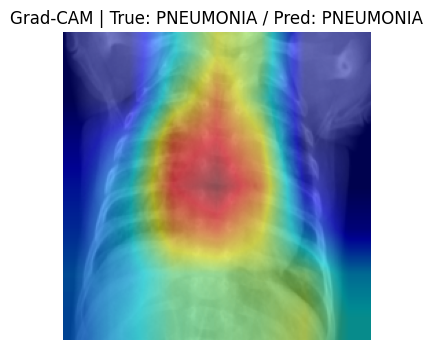

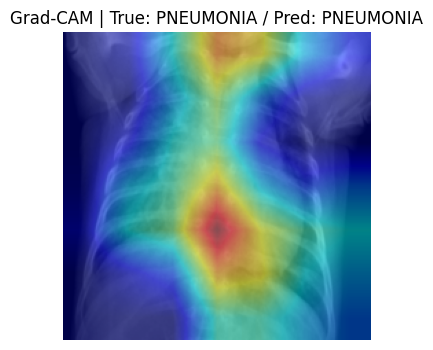

In [164]:
image_index = 345  # 시각화할 이미지 인덱스
# 예: ResNet18에서 layer4 마지막 레이어 사용
visualize_grad_cam(model=full_model18,
                   dataset=test_dataset,
                   index=image_index,
                   target_layer=full_model18.layer4[-1],
                   device=device)

# 예: ResNet50에서 layer4 마지막 레이어 사용
visualize_grad_cam(model=full_model50,
                   dataset=test_dataset,
                   index=image_index,
                   target_layer=full_model50.layer4[-1],
                   device=device)